ejercicio 1

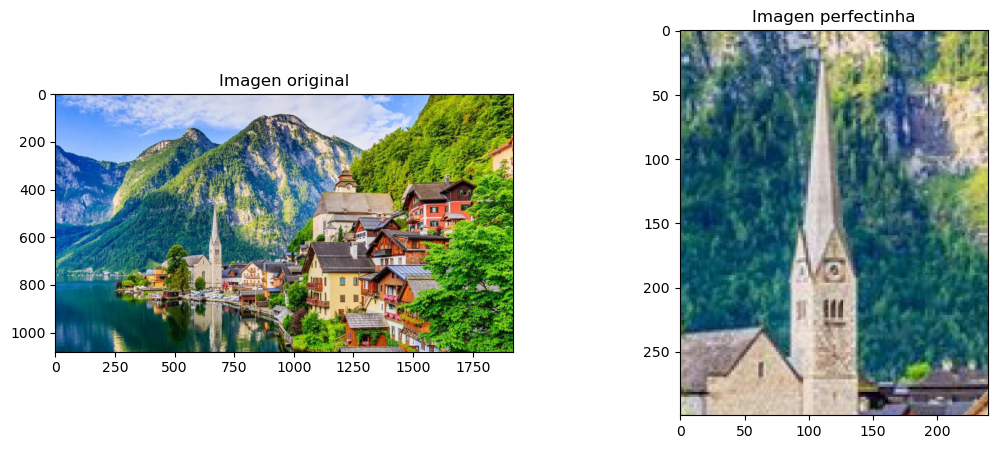

In [194]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('imagenP.jpg.jpeg')

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

recorte = img_rgb[440:740, 560:800]
plt.figure(figsize=(13,5))

plt.subplot(1,2,1)
plt.imshow(img_rgb)
plt.title('Imagen original')

plt.subplot(1,2,2)
plt.imshow(recorte)
plt.title('Imagen perfectinha')


plt.show()

ejercicio 3

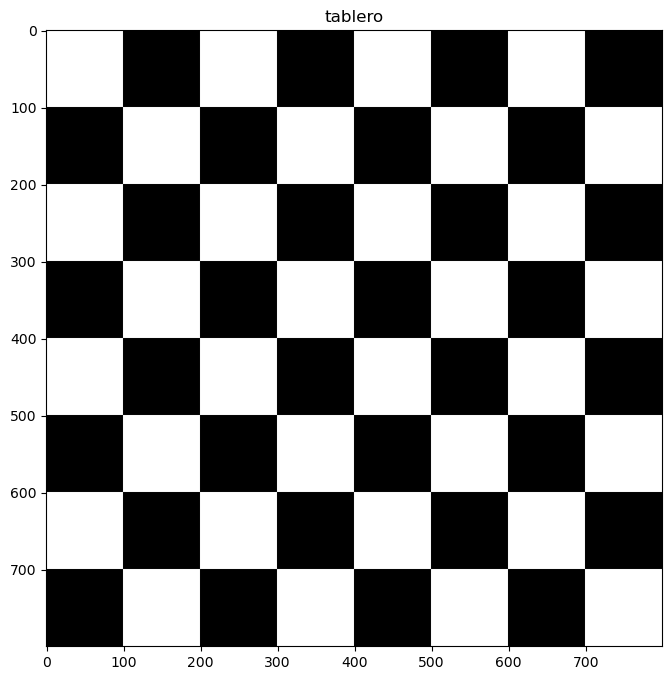

In [215]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = [8,8]

size_imagen = 100

def crear_color(r, g, b):
    R = np.ones((size_imagen, size_imagen)) * r
    G = np.ones((size_imagen, size_imagen)) * g
    B = np.ones((size_imagen, size_imagen)) * b
    img = np.dstack((R, G, B))
    return img.astype(np.uint8)

img_blanco     = crear_color(255, 255, 255)
img_negro   = crear_color(0, 0, 0)


fila1 = np.hstack((img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro))
fila2 = np.hstack((img_negro, img_blanco, img_negro,img_blanco,img_negro, img_blanco, img_negro,img_blanco))
fila3 = np.hstack((img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro))
fila4= np.hstack((img_negro, img_blanco, img_negro,img_blanco,img_negro, img_blanco, img_negro,img_blanco))
fila5= np.hstack((img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro))
fila6= np.hstack((img_negro, img_blanco, img_negro,img_blanco,img_negro, img_blanco, img_negro,img_blanco))
fila7= np.hstack((img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro, img_blanco , img_negro))
fila8= np.hstack((img_negro, img_blanco, img_negro,img_blanco,img_negro, img_blanco, img_negro,img_blanco))


mosaico = np.vstack((fila1, fila2, fila3,fila4,fila5,fila6,fila7,fila8))

plt.imshow(mosaico)
plt.title('tablero')
plt.axis('on')
plt.show()

ejercicio 2

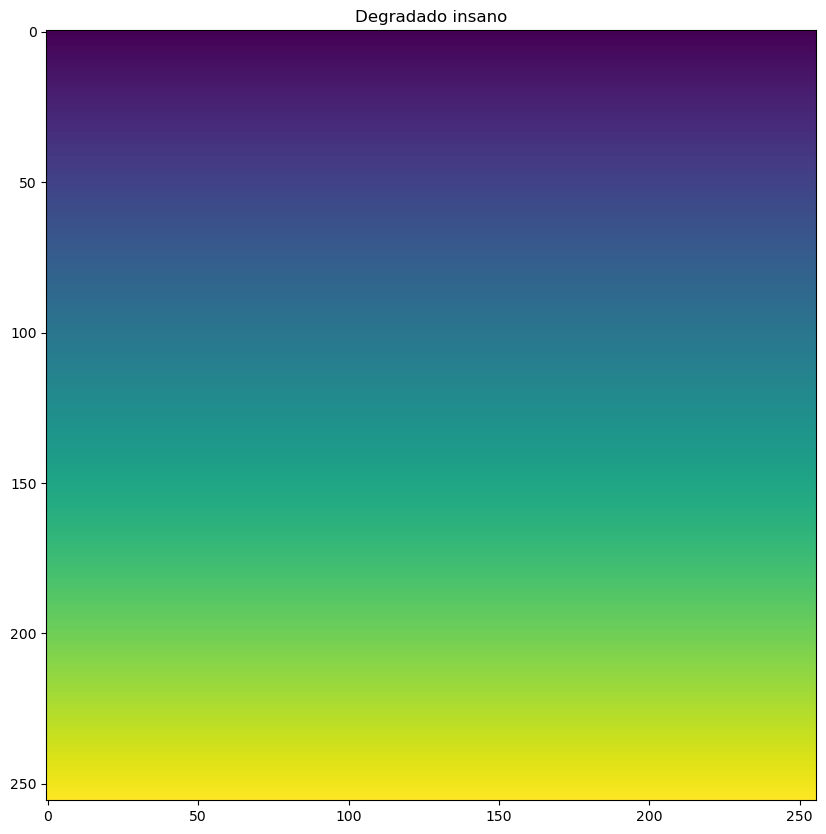

In [298]:
import numpy as np
import matplotlib.pyplot as plt

gradiente = np.linspace(0, 1, 256)
gradiente = np.tile(gradiente, (256, 1)).T
plt.figure(figsize=(35,10))
plt.imshow(gradiente, cmap='viridis')
plt.title("Degradado insano")
plt.axis('on')  
plt.show()

ejercicio 4 

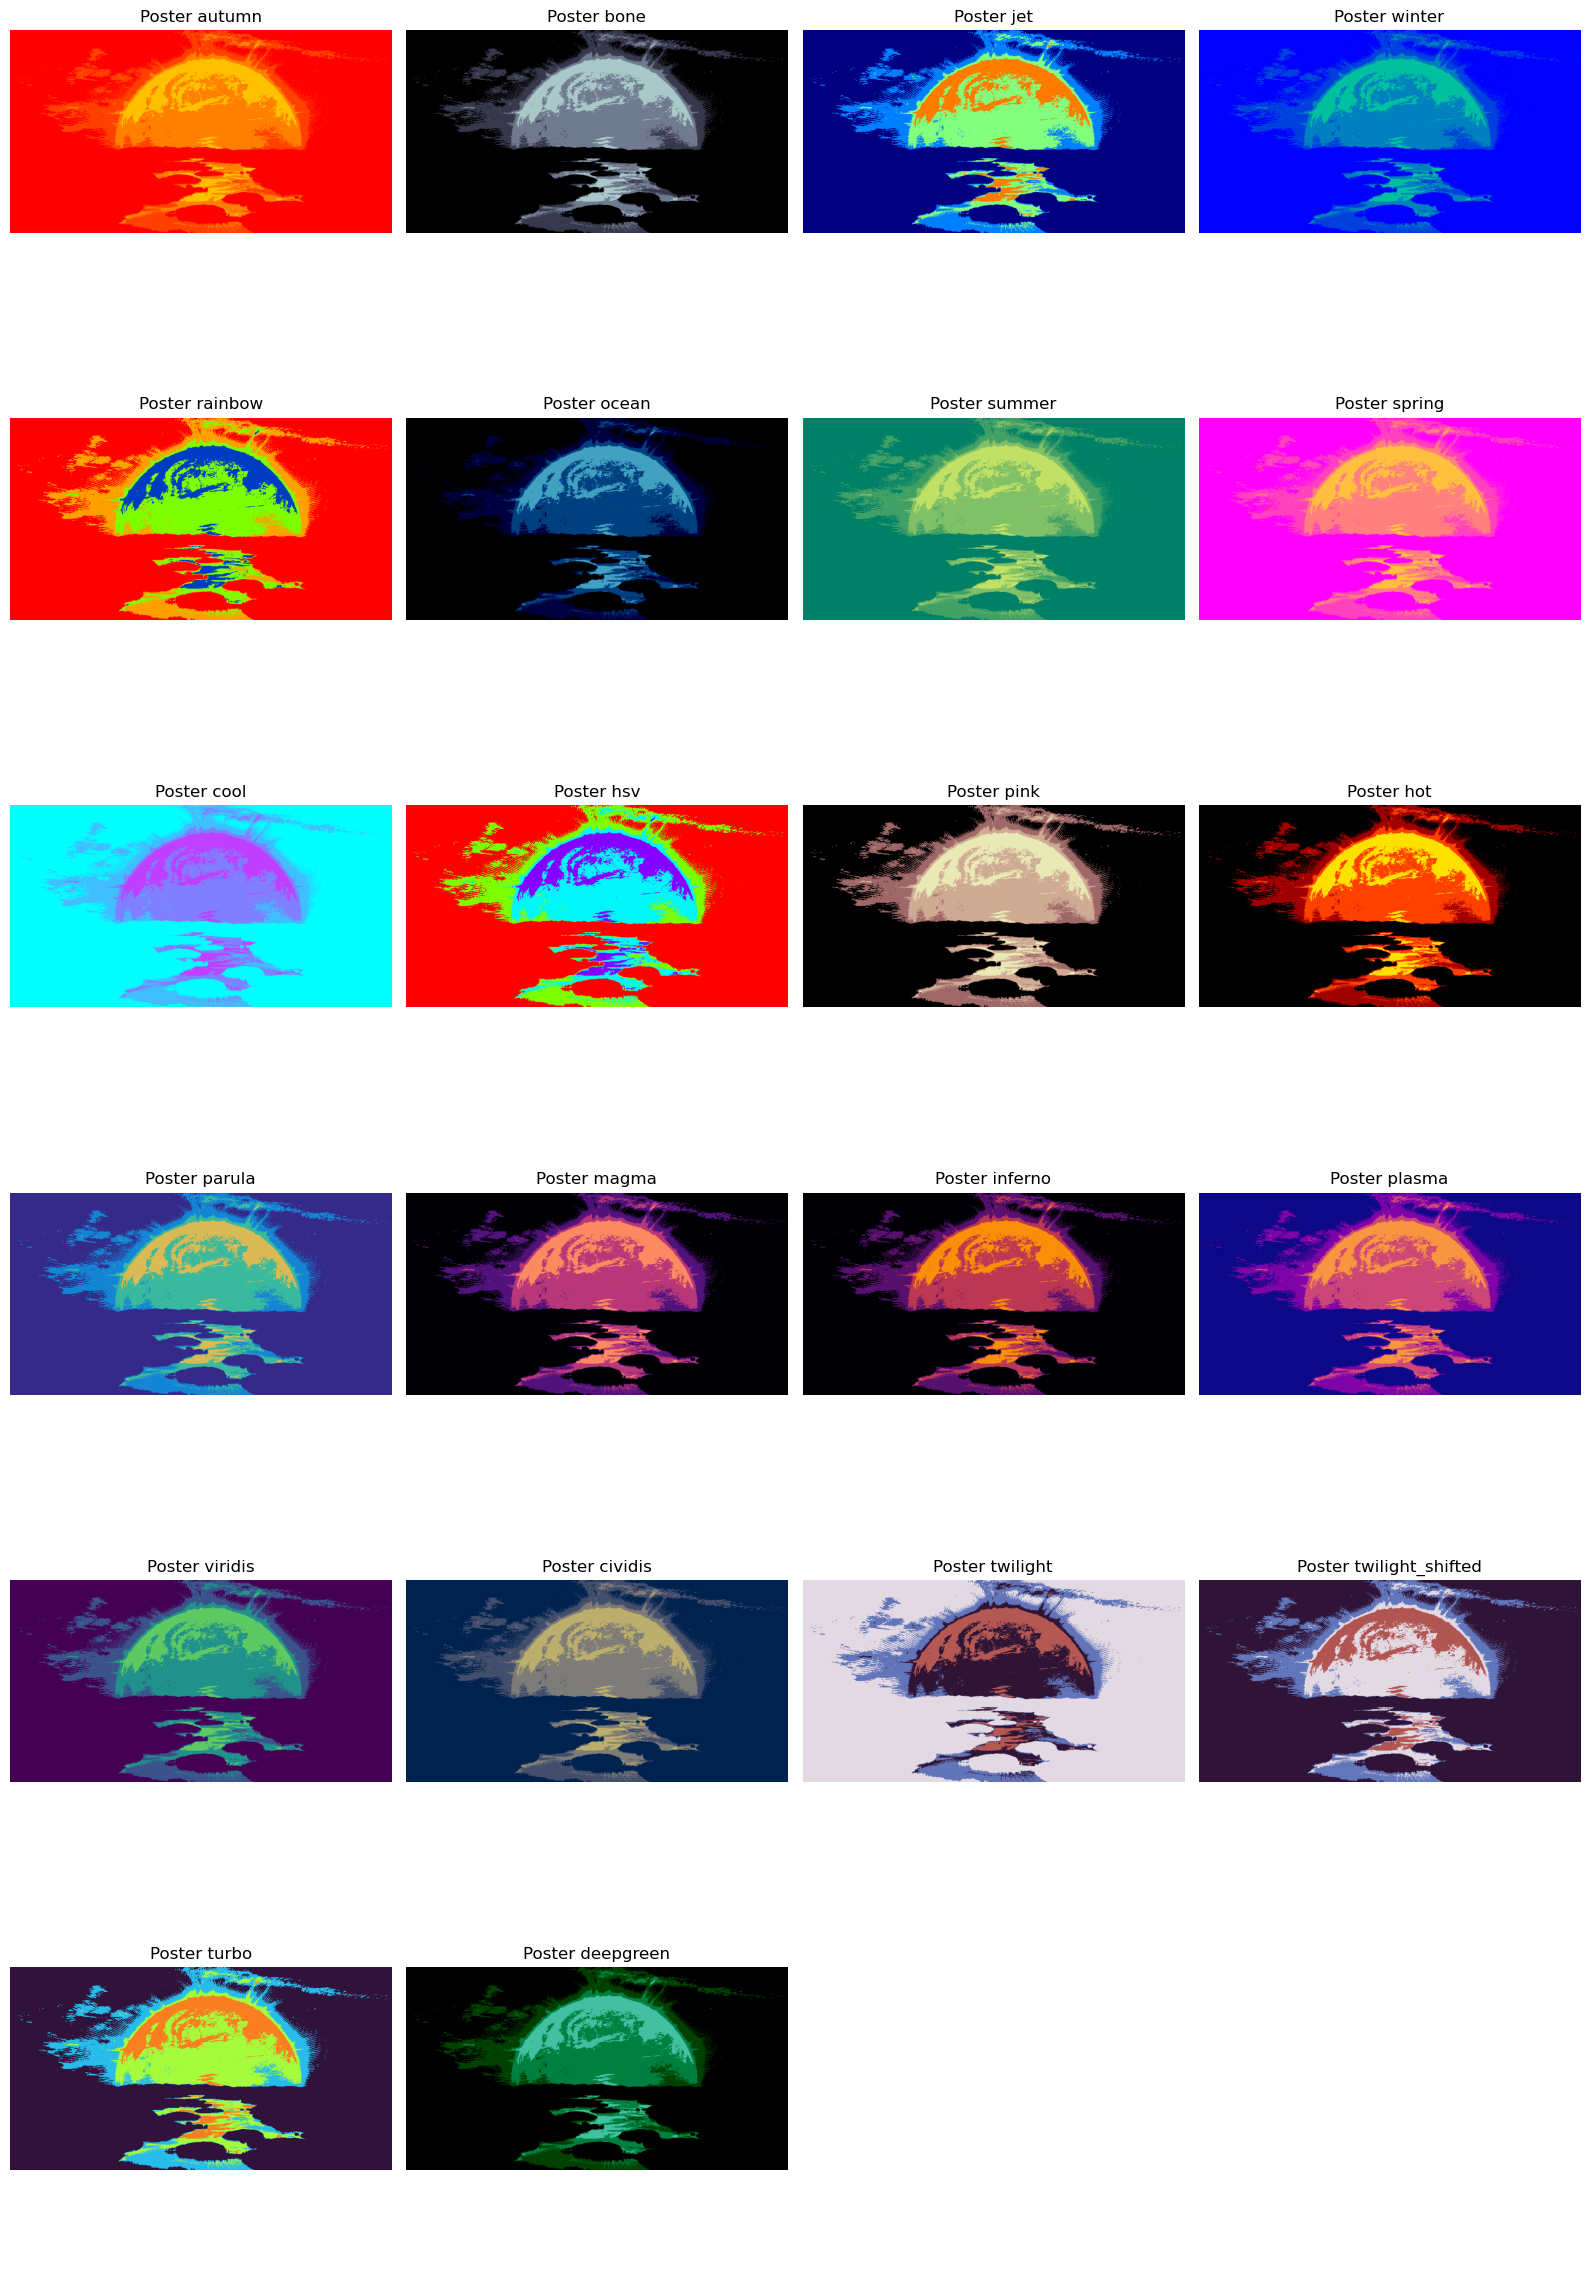

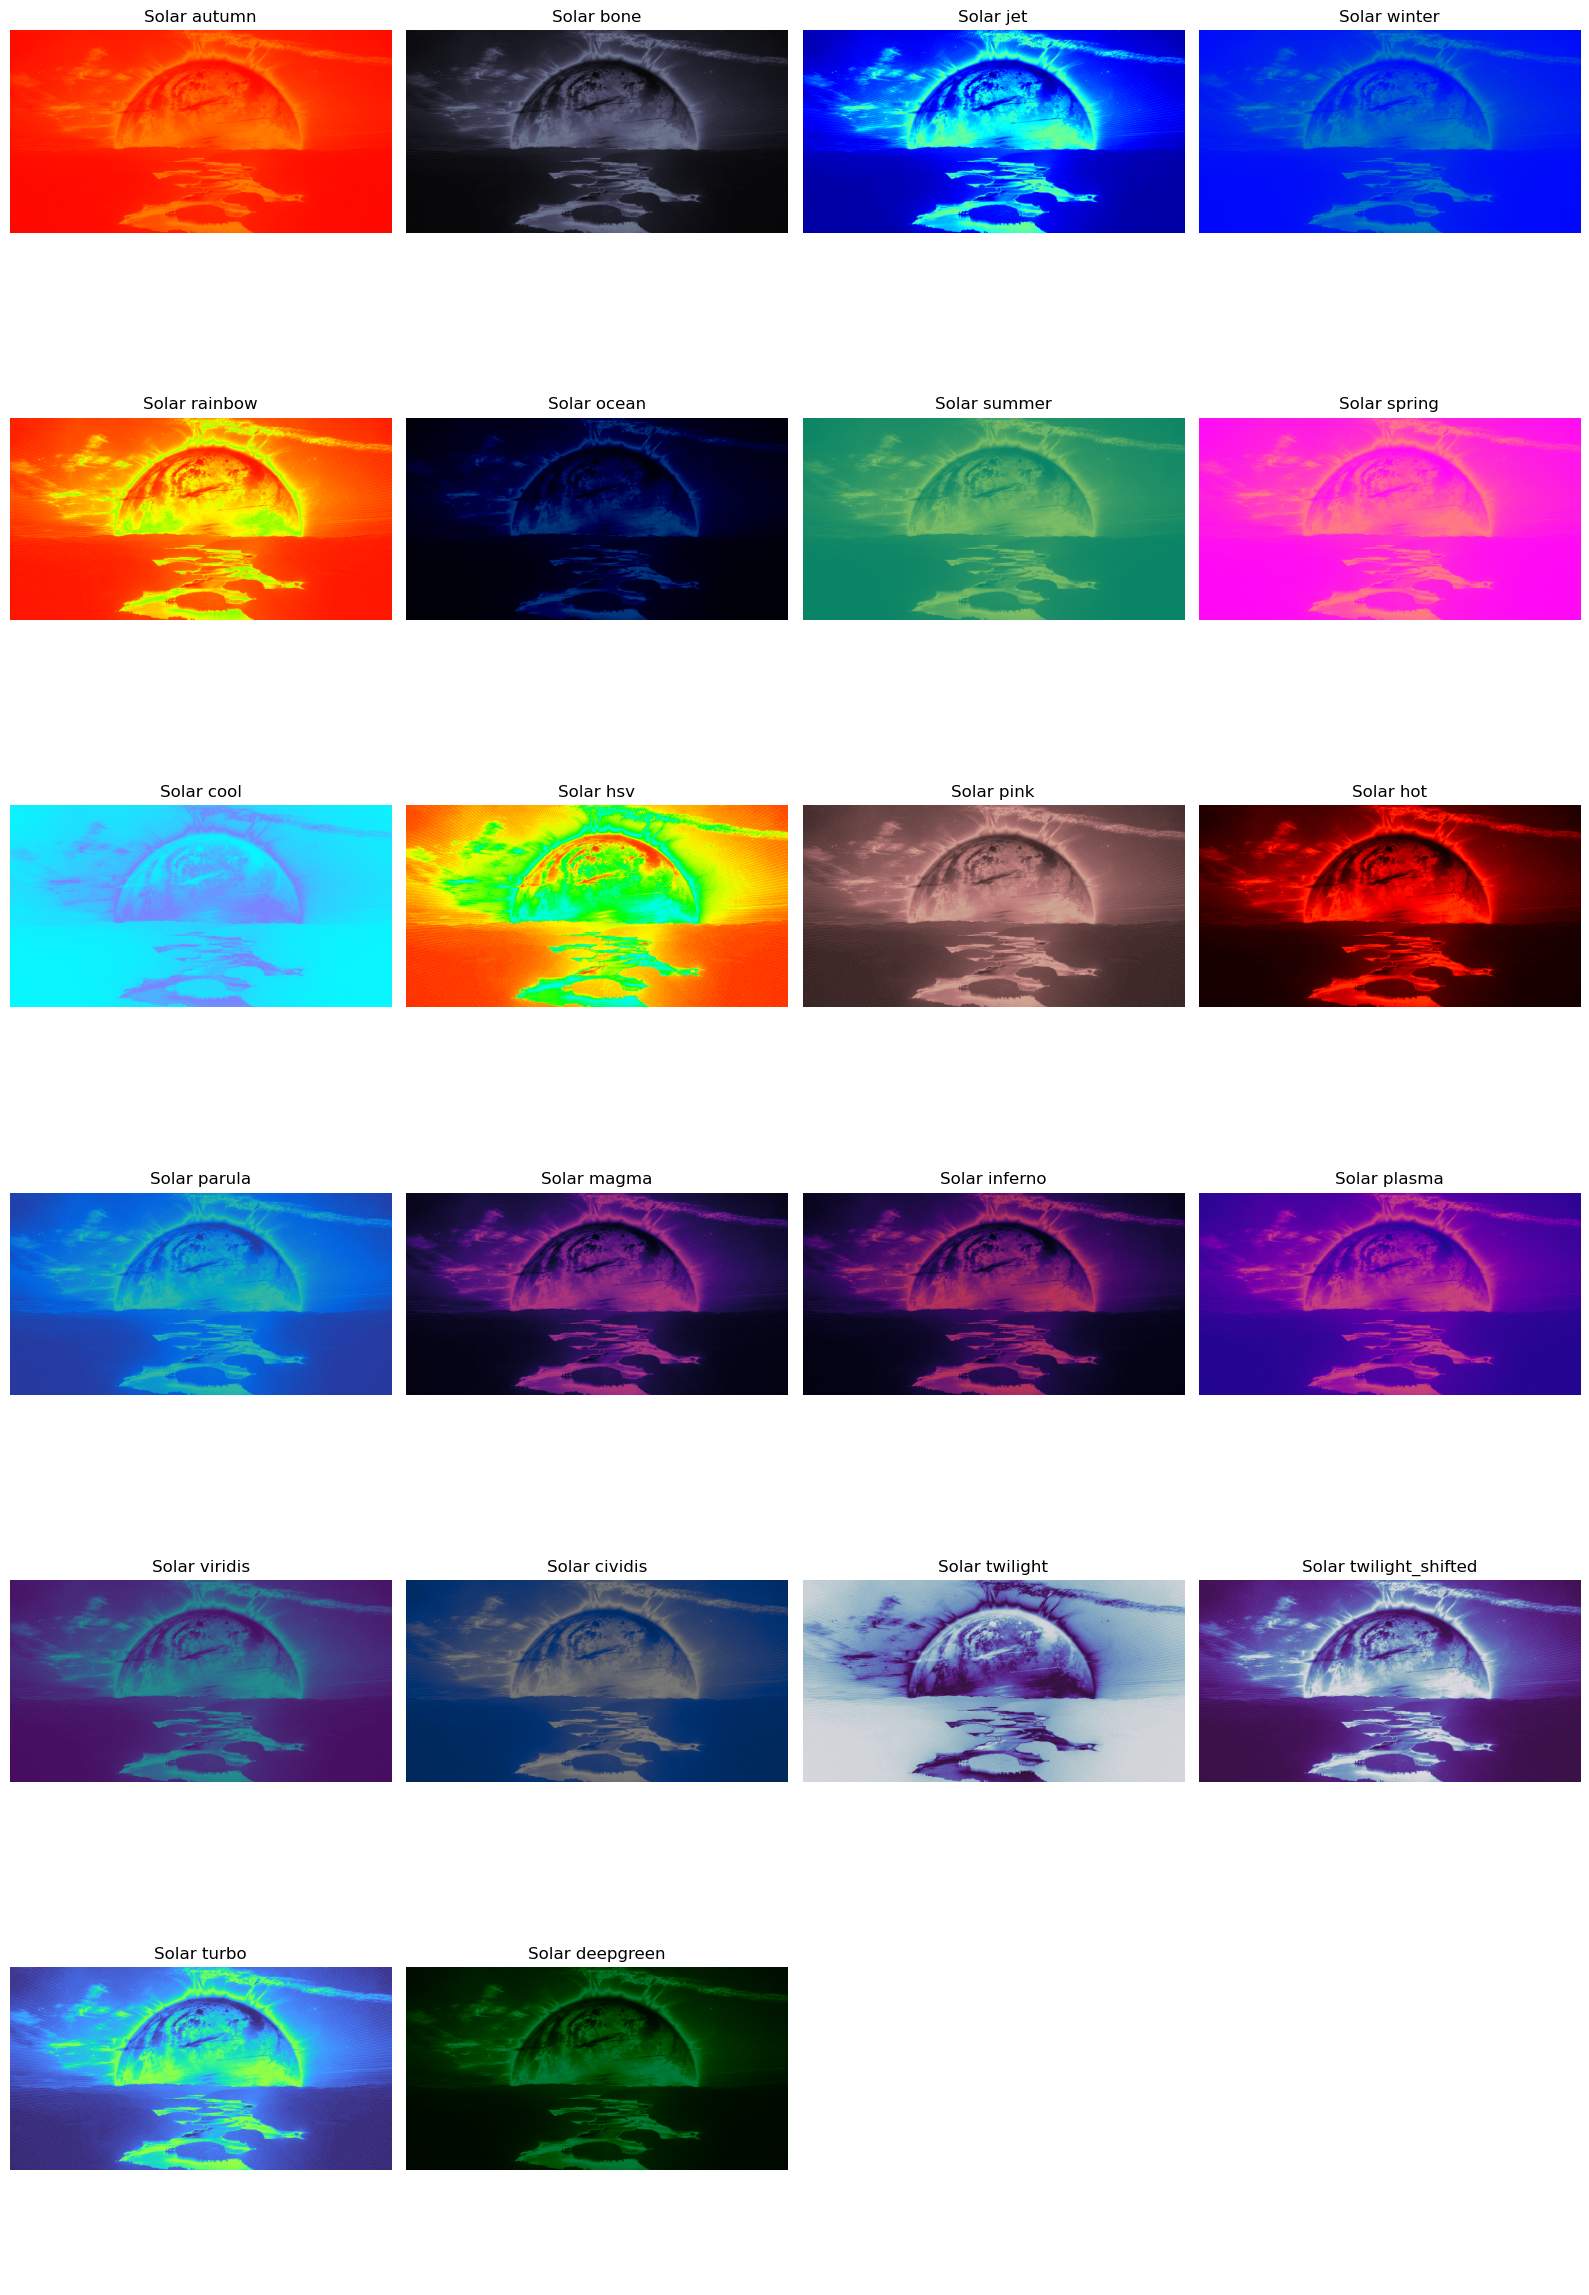

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("fondito.png")

if img is None:
    print("No se pudo cargar imagen_Deg.jpg")
else:
    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    niveles = 4
    paso = 256 // niveles
    poster = (gris // paso) * paso
    poster = poster.astype(np.uint8)

    umbral = 128
    solar = np.where(gris < umbral, gris, 255 - gris)
    solar = solar.astype(np.uint8)

    cv2.imwrite("posterizacion.jpg", poster)
    cv2.imwrite("solarizacion.jpg", solar)

    mapas = {
        "autumn": cv2.COLORMAP_AUTUMN,
        "bone": cv2.COLORMAP_BONE,
        "jet": cv2.COLORMAP_JET,
        "winter": cv2.COLORMAP_WINTER,
        "rainbow": cv2.COLORMAP_RAINBOW,
        "ocean": cv2.COLORMAP_OCEAN,
        "summer": cv2.COLORMAP_SUMMER,
        "spring": cv2.COLORMAP_SPRING,
        "cool": cv2.COLORMAP_COOL,
        "hsv": cv2.COLORMAP_HSV,
        "pink": cv2.COLORMAP_PINK,
        "hot": cv2.COLORMAP_HOT,
        "parula": cv2.COLORMAP_PARULA,
        "magma": cv2.COLORMAP_MAGMA,
        "inferno": cv2.COLORMAP_INFERNO,
        "plasma": cv2.COLORMAP_PLASMA,
        "viridis": cv2.COLORMAP_VIRIDIS,
        "cividis": cv2.COLORMAP_CIVIDIS,
        "twilight": cv2.COLORMAP_TWILIGHT,
        "twilight_shifted": cv2.COLORMAP_TWILIGHT_SHIFTED,
        "turbo": cv2.COLORMAP_TURBO,
        "deepgreen": cv2.COLORMAP_DEEPGREEN
    }

    for nombre, mapa in mapas.items():
        poster_color = cv2.applyColorMap(poster, mapa)
        solar_color = cv2.applyColorMap(solar, mapa)
        cv2.imwrite(f"poster_{nombre}.jpg", poster_color)
        cv2.imwrite(f"solar_{nombre}.jpg", solar_color)

    n = len(mapas)
    cols = 4
    rows = (n + cols - 1) // cols

    fig1, axes1 = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes1 = np.array(axes1).reshape(-1)

    for ax, (nombre, mapa) in zip(axes1, mapas.items()):
        img_color = cv2.applyColorMap(poster, mapa)
        img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Poster {nombre}")
        ax.axis("off")

    for ax in axes1[len(mapas):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    fig2, axes2 = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes2 = np.array(axes2).reshape(-1)

    for ax, (nombre, mapa) in zip(axes2, mapas.items()):
        img_color = cv2.applyColorMap(solar, mapa)
        img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(f"Solar {nombre}")
        ax.axis("off")

    for ax in axes2[len(mapas):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

ejercicio 5

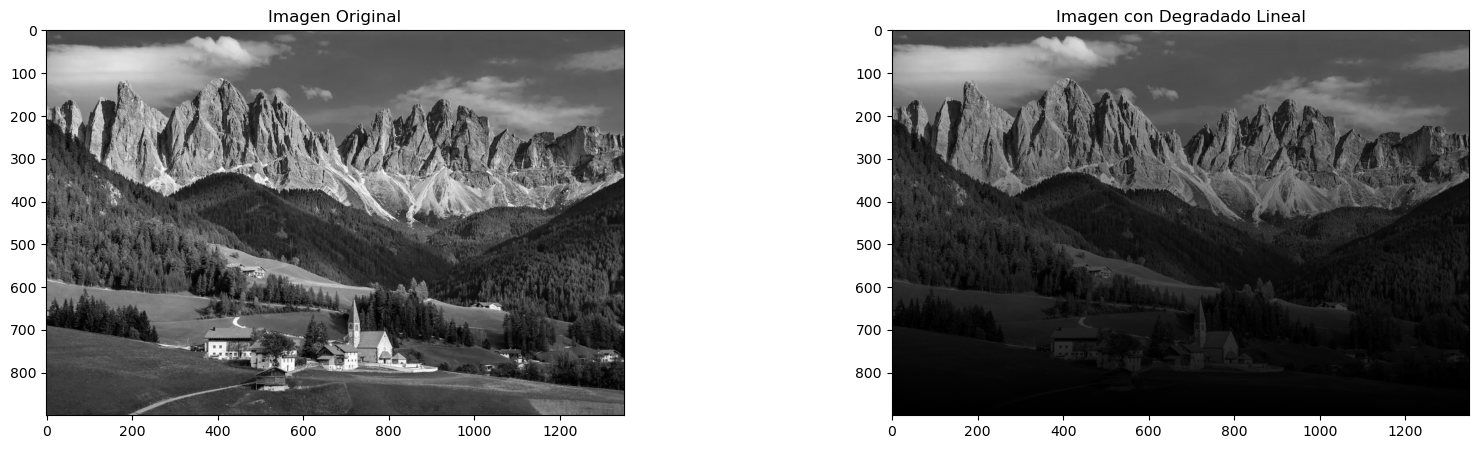

In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen1.jpg.jpeg', 0)

degradado = np.linspace(1, 0, imagen.shape[0])[:, np.newaxis]
mascara = np.tile(degradado, (1, imagen.shape[1]))
imagen_degradada = (imagen.astype(np.float32) * mascara).astype(np.uint8)

plt.figure(figsize=(20, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(imagen_degradada, cv2.COLOR_BGR2RGB))
plt.title('Imagen con Degradado Lineal')

plt.show()

ejercicio 6

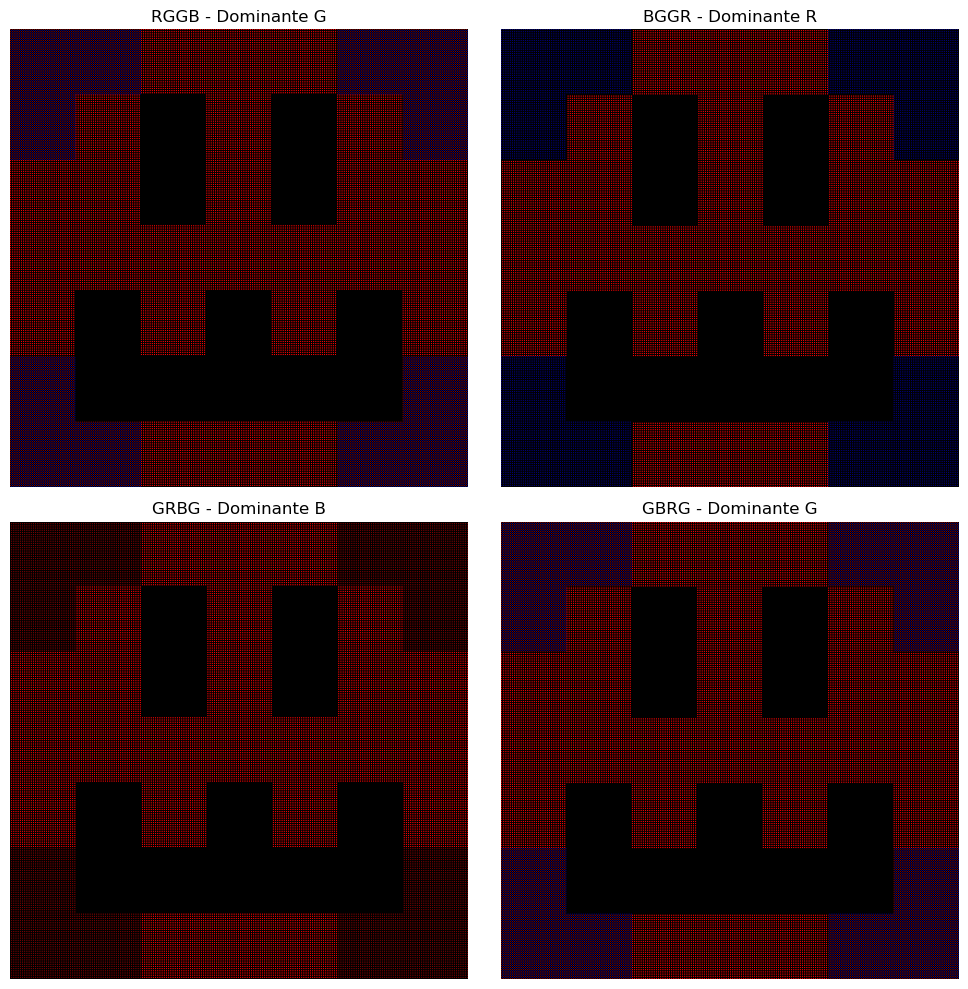

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

size = 60


BLANCO = [128, 0, 128]
NEGRO  = [0, 0, 0]
ROJO   = [255, 0, 0]


patron_cara = [
    [BLANCO, BLANCO, ROJO,  ROJO,  ROJO,  BLANCO, BLANCO],
    [BLANCO, ROJO,   NEGRO, ROJO,  NEGRO, ROJO,   BLANCO],
    [ROJO,   ROJO,   NEGRO, ROJO,  NEGRO, ROJO,   ROJO],
    [ROJO,   ROJO,   ROJO,  ROJO,  ROJO,  ROJO,   ROJO],
    [ROJO,   NEGRO,  ROJO,  NEGRO, ROJO,  NEGRO,  ROJO],
    [BLANCO, NEGRO,  NEGRO, NEGRO, NEGRO, NEGRO,  BLANCO],
    [BLANCO, BLANCO, ROJO,  ROJO,  ROJO,  BLANCO, BLANCO]
]

h, w = len(patron_cara), len(patron_cara[0])
cara = np.zeros((h*size, w*size, 3), dtype=np.uint8)
for i in range(h):
    for j in range(w):
        cara[i*size:(i+1)*size, j*size:(j+1)*size] = patron_cara[i][j]


def aplicar_bayer_destacado(img, patron="RGGB", dominante="G"):
    bayer = np.zeros_like(img)
    R, G, B = img[:,:,0], img[:,:,1], img[:,:,2]
    h, w = img.shape[:2]
    
    factor = 2 
    

    if patron == "RGGB":
        bayer[0:h:2,0:w:2,0] = R[0:h:2,0:w:2]
        bayer[0:h:2,1:w:2,1] = G[0:h:2,1:w:2]
        bayer[1:h:2,0:w:2,1] = G[1:h:2,0:w:2]
        bayer[1:h:2,1:w:2,2] = B[1:h:2,1:w:2]
    elif patron == "BGGR":
        bayer[0:h:2,0:w:2,2] = B[0:h:2,0:w:2]
        bayer[0:h:2,1:w:2,1] = G[0:h:2,1:w:2]
        bayer[1:h:2,0:w:2,1] = G[1:h:2,0:w:2]
        bayer[1:h:2,1:w:2,0] = R[1:h:2,1:w:2]
    elif patron == "GRBG":
        bayer[0:h:2,0:w:2,1] = G[0:h:2,0:w:2]
        bayer[0:h:2,1:w:2,0] = R[0:h:2,1:w:2]
        bayer[1:h:2,0:w:2,2] = B[1:h:2,0:w:2]
        bayer[1:h:2,1:w:2,1] = G[1:h:2,1:w:2]
    else:  
        bayer[0:h:2,0:w:2,1] = G[0:h:2,0:w:2]
        bayer[0:h:2,1:w:2,2] = B[0:h:2,1:w:2]
        bayer[1:h:2,0:w:2,0] = R[1:h:2,0:w:2]
        bayer[1:h:2,1:w:2,1] = G[1:h:2,1:w:2]
    
   
    if dominante == "R":
        bayer[:,:,0] = np.clip(bayer[:,:,0]*factor,0,255)
    elif dominante == "G":
        bayer[:,:,1] = np.clip(bayer[:,:,1]*factor,0,255)
    elif dominante == "B":
        bayer[:,:,2] = np.clip(bayer[:,:,2]*factor,0,255)
    
    return bayer.astype(np.uint8)

patrones = ["RGGB", "BGGR", "GRBG", "GBRG"]
dominantes = ["G", "R", "B", "G"]

fig, axs = plt.subplots(2, 2, figsize=(10,10))

for i, (p, d) in enumerate(zip(patrones,dominantes)):
    ax = axs[i//2,i%2]
    ax.imshow(aplicar_bayer_destacado(cara,p,d))
    ax.set_title(f"{p} - Dominante {d}")
    ax.axis("off")

plt.tight_layout()
plt.show()